In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_excel('EastWestAirlines.xlsx', sheet_name=1)
df.shape

(3999, 12)

In [3]:
df.head()

,ID#,Balance,Qual_miles,cc1_miles,cc2_miles,cc3_miles,Bonus_miles,Bonus_trans,Flight_miles_12mo,Flight_trans_12,Days_since_enroll,Award?
0,1,28143,0,1,1,1,174,1,0,0,7000,0
1,2,19244,0,1,1,1,215,2,0,0,6968,0
2,3,41354,0,1,1,1,4123,4,0,0,7034,0
3,4,14776,0,1,1,1,500,1,0,0,6952,0
4,5,97752,0,4,1,1,43300,26,2077,4,6935,1


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3999 entries, 0 to 3998
Data columns (total 12 columns):
 #   Column             Non-Null Count  Dtype
---  ------             --------------  -----
 0   ID#                3999 non-null   int64
 1   Balance            3999 non-null   int64
 2   Qual_miles         3999 non-null   int64
 3   cc1_miles          3999 non-null   int64
 4   cc2_miles          3999 non-null   int64
 5   cc3_miles          3999 non-null   int64
 6   Bonus_miles        3999 non-null   int64
 7   Bonus_trans        3999 non-null   int64
 8   Flight_miles_12mo  3999 non-null   int64
 9   Flight_trans_12    3999 non-null   int64
 10  Days_since_enroll  3999 non-null   int64
 11  Award?             3999 non-null   int64
dtypes: int64(12)
memory usage: 375.0 KB


In [5]:
df.describe()

,ID#,Balance,Qual_miles,cc1_miles,cc2_miles,cc3_miles,Bonus_miles,Bonus_trans,Flight_miles_12mo,Flight_trans_12,Days_since_enroll,Award?
count,3999.000000,3.999000e+03,3999.000000,3999.000000,3999.000000,3999.000000,3999.000000,3999.00000,3999.000000,3999.000000,3999.00000,3999.000000
mean,2014.819455,7.360133e+04,144.114529,2.059515,1.014504,1.012253,17144.846212,11.60190,460.055764,1.373593,4118.55939,0.370343
std,1160.764358,1.007757e+05,773.663804,1.376919,0.147650,0.195241,24150.967826,9.60381,1400.209171,3.793172,2065.13454,0.482957
min,1.000000,0.000000e+00,0.000000,1.000000,1.000000,1.000000,0.000000,0.00000,0.000000,0.000000,2.00000,0.000000
25%,1010.500000,1.852750e+04,0.000000,1.000000,1.000000,1.000000,1250.000000,3.00000,0.000000,0.000000,2330.00000,0.000000
50%,2016.000000,4.309700e+04,0.000000,1.000000,1.000000,1.000000,7171.000000,12.00000,0.000000,0.000000,4096.00000,0.000000
75%,3020.500000,9.240400e+04,0.000000,3.000000,1.000000,1.000000,23800.500000,17.00000,311.000000,1.000000,5790.50000,1.000000
max,4021.000000,1.704838e+06,11148.000000,5.000000,3.000000,5.000000,263685.000000,86.00000,30817.000000,53.000000,8296.00000,1.000000


In [6]:
df.isna().sum()

ID#                  0
Balance              0
Qual_miles           0
cc1_miles            0
cc2_miles            0
cc3_miles            0
Bonus_miles          0
Bonus_trans          0
Flight_miles_12mo    0
Flight_trans_12      0
Days_since_enroll    0
Award?               0
dtype: int64

- there are no null values in the dataset

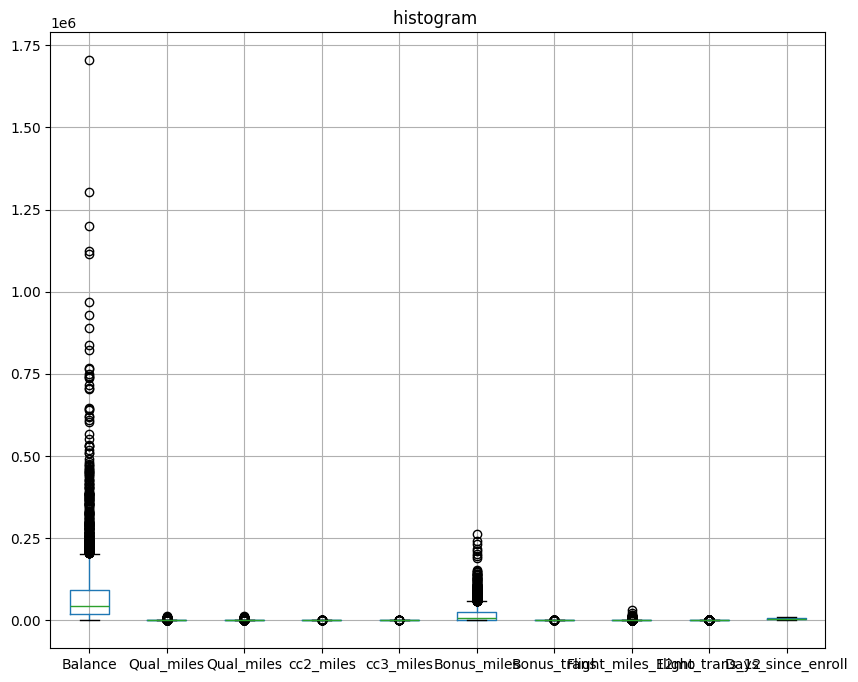

In [10]:
cols = ['Balance', 'Qual_miles', 'Qual_miles', 'cc2_miles', 'cc3_miles', 'Bonus_miles', 'Bonus_trans', 'Flight_miles_12mo', 'Flight_trans_12', 'Days_since_enroll']

df[cols].boxplot(figsize=(10,8))
plt.title("histogram ")
plt.show()

<Axes: >

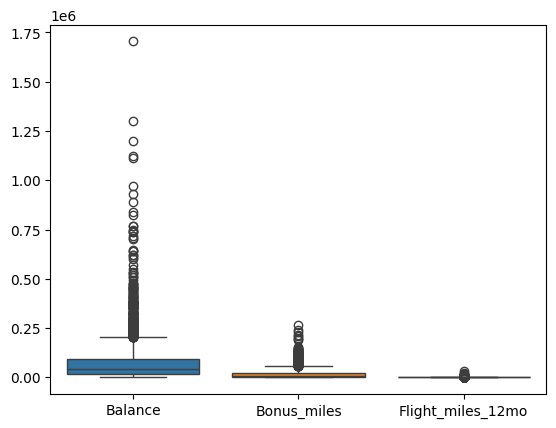

In [14]:
cols_2 = ["Balance", "Bonus_miles", "Flight_miles_12mo"]

sns.boxplot(data =df[cols_2])

<Axes: ylabel='Flight_miles_12mo'>

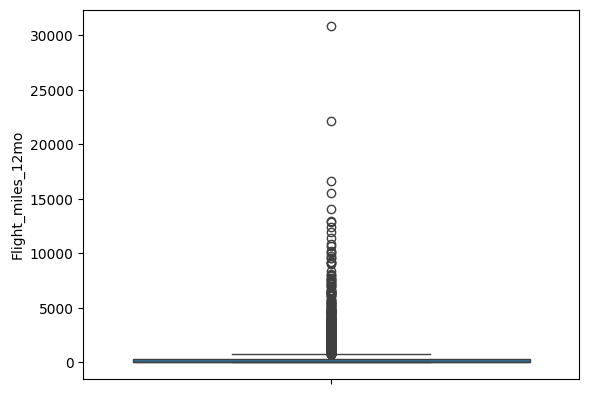

In [15]:
sns.boxplot(y =df["Flight_miles_12mo"])

<Axes: ylabel='Qual_miles'>

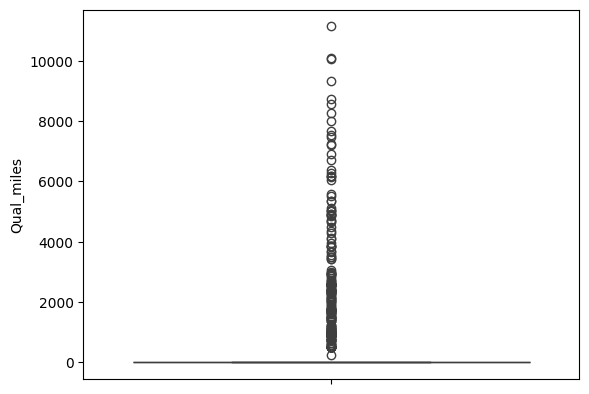

In [17]:
sns.boxplot(y =df["Qual_miles"])

- almost all the columns have extream outliers or density of the values are around the mean
- we need to handel these outliers
- Instead of just log transformation, use PowerTransformer. It applies a Yeo-Johnson transformation, which is specifically designed to make skewed data look more like a "Normal Distribution" (Gaussian). This makes clustering algorithms perform much better.

In [22]:
from sklearn.preprocessing import PowerTransformer, RobustScaler

In [19]:
pt = PowerTransformer(method='yeo-johnson')
df_transformed = pt.fit_transform(df)

- Even after transforming, keep using RobustScaler. It centers the data around the median rather than the mean, ensuring that the remaining extreme values don't pull the center of your data away from the "average" user.

In [24]:
scaler = RobustScaler()
data_scaled = scaler.fit_transform(df_transformed)

In [26]:
data_scaled = pd.DataFrame(data_scaled)
data_scaled.columns = ['ID#', 'Balance', 'Qual_miles', 'cc1_miles', 'cc2_miles', 'cc3_miles', 'Bonus_miles', 'Bonus_trans', 'Flight_miles_12mo', 'Flight_trans_12', 'Days_since_enroll', 'Award?']
data_scaled.head()

,ID#,Balance,Qual_miles,cc1_miles,cc2_miles,cc3_miles,Bonus_miles,Bonus_trans,Flight_miles_12mo,Flight_trans_12,Days_since_enroll,Award?
0,-1.377060,-0.257279,0.0,0.000000,0.0,0.0,-0.888778,-1.022274,0.000000,0.000000,0.763229,0.0
1,-1.373671,-0.472329,0.0,0.000000,0.0,0.0,-0.855940,-0.861082,0.000000,0.000000,0.755377,0.0
2,-1.370600,-0.025703,0.0,0.000000,0.0,0.0,-0.184356,-0.616717,0.000000,0.000000,0.771561,0.0
3,-1.367746,-0.614238,0.0,0.000000,0.0,0.0,-0.707787,-1.022274,0.000000,0.000000,0.751447,0.0
4,-1.365053,0.546834,0.0,1.149512,0.0,0.0,0.787737,0.660697,1.072093,1.344437,0.747269,1.0


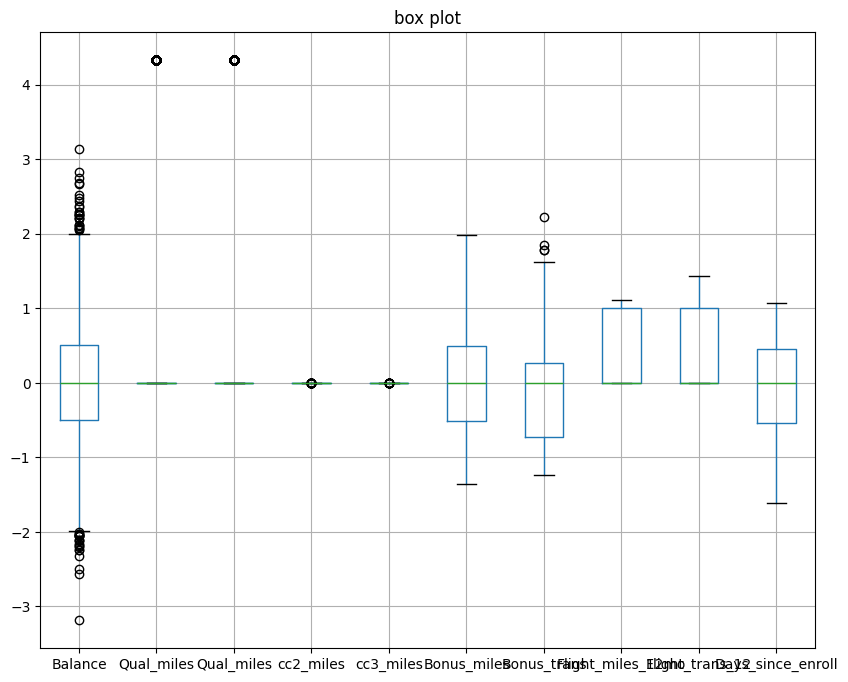

In [29]:
cols = ['Balance', 'Qual_miles', 'Qual_miles', 'cc2_miles', 'cc3_miles', 'Bonus_miles', 'Bonus_trans', 'Flight_miles_12mo', 'Flight_trans_12', 'Days_since_enroll']

data_scaled[cols].boxplot(figsize=(10,8))
plt.title("box plot")
plt.show()

- now it is some what balanced

#### Implementing Clustering Algorithms:

In [28]:
from sklearn.cluster import KMeans, DBSCAN
from sklearn.metrics import silhouette_score

- K-Means requires you to specify the number of clusters ($K$) beforehand. The Elbow Method helps you find the optimal $K$ by measuring the sum of squared distances of samples to their closest cluster center (inertia).

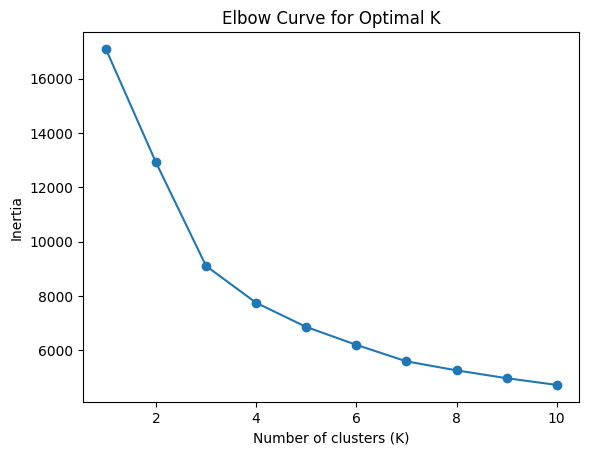

In [30]:
inertia = []
K_range = range(1, 11)

for k in K_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(data_scaled)
    inertia.append(kmeans.inertia_)

# Plot the Elbow Curve
plt.plot(K_range, inertia, marker='o')
plt.xlabel('Number of clusters (K)')
plt.ylabel('Inertia')
plt.title('Elbow Curve for Optimal K')
plt.show()

- "elbow" point—where the decrease in inertia slows down significantly. This is your optimal K
- The "elbow" represents the point of diminishing returns. Adding a 4th or 5th cluster provides relatively little extra benefit in terms of reducing the variance (inertia) within the groups. By choosing $K=3$, you balance model simplicity (easier to interpret) with the need to capture the distinct patterns in your data.

In [31]:
best_k = 3 
kmeans = KMeans(n_clusters=best_k, random_state=42, n_init=10)
df['KMeans_Cluster'] = kmeans.fit_predict(data_scaled)

In [32]:
print(df.groupby('KMeans_Cluster').mean())

                        ID#        Balance   Qual_miles  cc1_miles  cc2_miles  \
KMeans_Cluster                                                                  
0               1651.153846  109511.520790     0.000000   3.018191   1.013514   
1               1875.539823  133049.712389  2550.061947   2.185841   1.008850   
2               2410.260141   28968.257436     0.000000   1.046512   1.016225   

                cc3_miles   Bonus_miles  Bonus_trans  Flight_miles_12mo  \
KMeans_Cluster                                                            
0                1.024428  30288.964137    17.325884         605.371102   
1                1.008850  24165.995575    15.584071        1720.057522   
2                1.000000   2609.387777     5.159005         154.838291   

                Flight_trans_12  Days_since_enroll    Award?  
KMeans_Cluster                                                
0                      1.795218        4788.434511  0.535863  
1                      5.1902

In [33]:
dbscan = DBSCAN(eps=0.5, min_samples=10) 
df['DBSCAN_Cluster'] = dbscan.fit_predict(data_scaled)

In [34]:
# Check results
print(df['DBSCAN_Cluster'].value_counts())

DBSCAN_Cluster
 1     1265
-1     1059
 2      574
 3      427
 0      228
 6      222
 4       92
 12      34
 8       26
 13      14
 10      14
 5       10
 7       10
 14       9
 11       8
 9        7
Name: count, dtype: int64


#### Cluster Analysis and Interpretation:

K-means
- Cluster 0-> High Balance / High Flyers: These users have high balances (109,511) and relatively high bonus miles. They seem to be your most active, "VIP" users.
- Cluster 1-> Frequent Travelers: These users have the highest Qual_miles (2,550) and Flight_miles_12mo. They are likely business travelers who fly frequently rather than just accumulating points via credit cards.
- Cluster 2-> Casual Users / Low Activity: This is your largest group. They have the lowest balances (28,968) and minimal flight activity. These are likely infrequent users or members who signed up but don't use the program often.

DB-scan
- The "-1" Cluster (1,059 points): In DBSCAN, this is your Noise. These 1,059 individuals did not fit into any dense region. These are your true outliers—customers who behave in unique ways that don't match the general population.

- The "1" Cluster (1,265 points): This is the largest dense group. Given it contains more than half your dataset, this represents the "standard" or "typical" customer behavior in your database.

- Other Clusters (2 through 14): These are small, highly specific niches. For example, Cluster 2 (574 members) and Cluster 3 (427 members) represent smaller, tighter groups of customers who share very similar behaviors.

Insights:

- DBSCAN vs. K-Means: DBSCAN is showing you that a huge portion of your data (the noise) is "atypical." K-Means forced everyone into three boxes, but DBSCAN is correctly pointing out that over 1,000 of your customers don't actually fit into the "standard" patterns.

- Actionable takeaway: Analyze the "Noise" (-1). Are these your highest-net-worth individuals? Or are they data entry errors? Since DBSCAN identified them as "not similar to others," they are likely the most extreme cases in your dataset.

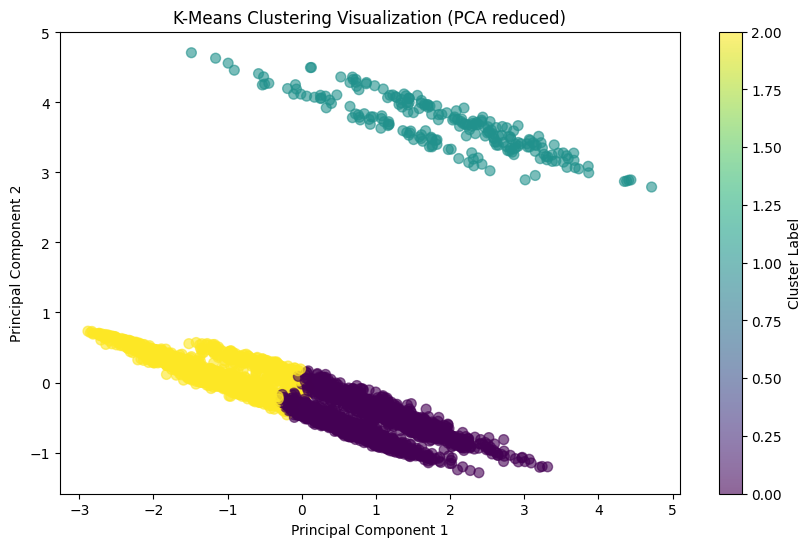

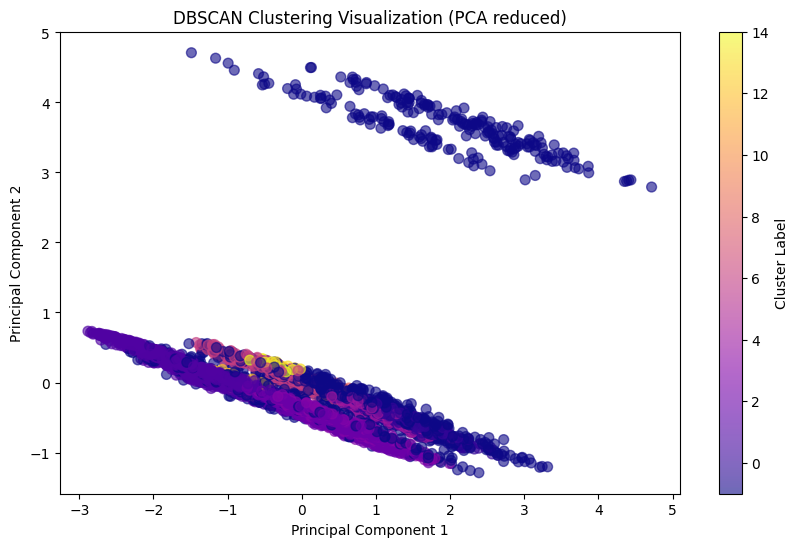

In [35]:
from sklearn.decomposition import PCA

# 1. Reduce dimensionality to 2D for plotting
pca = PCA(n_components=2)
data_2d = pca.fit_transform(data_scaled)

# 2. Plotting K-Means Result
plt.figure(figsize=(10, 6))
plt.scatter(data_2d[:, 0], data_2d[:, 1], c=df['KMeans_Cluster'], cmap='viridis', s=50, alpha=0.6)
plt.title('K-Means Clustering Visualization (PCA reduced)')
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.colorbar(label='Cluster Label')
plt.show()

# 3. Plotting DBSCAN Result
plt.figure(figsize=(10, 6))
plt.scatter(data_2d[:, 0], data_2d[:, 1], c=df['DBSCAN_Cluster'], cmap='plasma', s=50, alpha=0.6)
plt.title('DBSCAN Clustering Visualization (PCA reduced)')
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.colorbar(label='Cluster Label')
plt.show()

Interpreting the Visualization
- K-Means Plot: You should see three distinct "blobs" of color. If the colors overlap significantly, it suggests that your clusters are not well-separated and your choice of $K$ or the features used might need adjustment.
- DBSCAN Plot: You will likely see one large, dense area (the main cluster) and many points scattered around the edges or far away (the noise, labeled as -1). If the plot shows a large blob with a lot of "noise" points around it, it confirms that DBSCAN is correctly identifying atypical user behavior.

#### Evaluation and Performance Metrics:

In [36]:
score_kmeans = silhouette_score(data_scaled, df['KMeans_Cluster'])
print(f"K-Means Silhouette Score (K=3): {score_kmeans:.3f}")

K-Means Silhouette Score (K=3): 0.286


In [ ]:
# Evaluate with Silhouette Score (High score indicates good clustering)
# Note: Silhouette score can be negative for noise (-1)
print(f"Silhouette Score: {silhouette_score(data_scaled, df['DBSCAN_Cluster'])}")

Silhouette Score: -0.0626732929415826
